In [1]:
pip install biopython

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.3/3.3 MB 35.1 MB/s eta 0:00:00


Ejercicio 3.1 Dot-Plot y filtros

a) cree una matriz de ceros (de dimensión de acuerdo a las longitudes de seq1 y se2) y luego recorra todas las casillas poniendo 1 donde hay un match y 0 donde hay mismatch (consejo pruebe con una matriz más pequeña y luego vaya por la  completa).

b) Arme un modulo para graficar el dot-plot.

c) Programe un filtro que -opere sobre el dot-plot obtenido (el window-size “w” debería ser una variable a modificar), y reanalice los resultados. Hay varias alternativas para programar el filtro, como ser relacionadas con si las ventanas se encuentran superpuestas o son adyacentes, y si el dotplot es reemplazado por el dotplot de las ventanas y/o las mismas son solo utilizadas como filtro. Ademas se puede setear el umbral (vea el grafico para mayor claridad). Programe y compare las diferentes opciones.

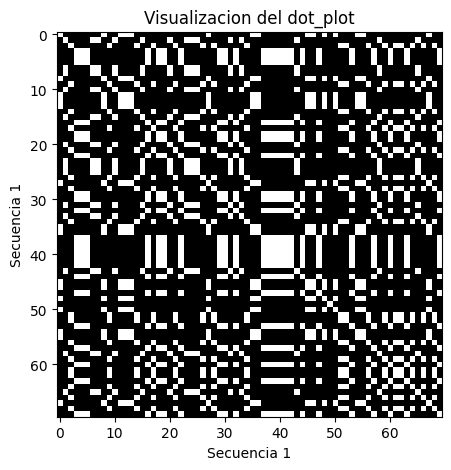

In [2]:
import numpy as np
from Bio.Seq import Seq
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# Me quedo solo con la secuencia que es lo que me interesa
#seq1 = records[0].seq
#seq2 = records[1].seq

seq1 = "TCGAAACCTGCTTTGCAGAACGACCCGTGAACACGTTAAAAAACATTATRTGGATTGACGAGGAGCGTGA"
seq2 = "GCTCTTAATCATCCATTGTCGGGTCATGGGATYGACCATGGTTGATCTTATGCTCTCGTACAAACACAAA"
def generar_dotplot(seq1, seq2, tipo="nucleotido", matriz=None):
    seq1, seq2 = str(seq1), str(seq2)
    dot_plot = np.zeros((len(seq1), len(seq2)))

    for i, a1 in enumerate(seq1):
        for j, a2 in enumerate(seq2):
            if tipo == "nucleotido":
                dot_plot[i, j] = 1 if a1 == a2 else 0
            elif tipo == "aminoacido":
                if matriz is None:
                    raise ValueError("Debes pasar una matriz de sustitución (ej. BLOSUM60)")
                if a1 in matriz.index and a2 in matriz.columns:
                    dot_plot[i, j] = matriz.loc[a1, a2]
                else:
                    dot_plot[i, j] = 0  # por si hay caracteres no estándar
            else:
                raise ValueError("El parámetro 'tipo' debe ser 'nucleotido' o 'aminoacido'")
    return dot_plot

dotplot = generar_dotplot(seq1,seq1, "nucleotido")
plt.figure(figsize=(10,5))
plt.imshow(dotplot, cmap='gray', vmin=0, vmax=1, interpolation='nearest')
plt.xlabel("Secuencia 1")
plt.ylabel("Secuencia 1")
plt.title("Visualizacion del dot_plot")
plt.show()



El siguiente algoritmo consigue un alineamiento global. Por lo que considera que la solucion empieza en la posicion (0,0) y en una matriz de nxn, el camino mas optimo terminara en la celda (n,n)

In [3]:
secuencia1 = "ACGTTCAGTAG"
secuencia2 = "ACCACTTG"

def puntaje_acum_blosum(s1, s2, blosum):
    n, m = len(s1), len(s2)
    dp = np.zeros((n+1, m+1), dtype=int)

    for i in range(1, n+1):
        for j in range(1, m+1):
            aa1 = s1[i-1]
            aa2 = s2[j-1]

            try:
                score_sub = blosum.loc[aa1, aa2]
            except KeyError:
                # Si uno de los aminoácidos no está en la matriz, usar score neutro
                score_sub = -1

            # Puntajes posibles:
            # - reemplazo (diagonal)
            # - eliminación (arriba)
            # - inserción (izquierda)
            dp[i, j] = max(
                dp[i-1, j-1] + score_sub,  # reemplazo o coincidencia
                dp[i-1, j],                # eliminación
                dp[i, j-1]                 # inserción
            )

    return dp


# Alineamiento de proteinas de a pares

Cargamos la matriz blosum60, y realizamos un grafico de distribuciones

In [4]:
import pandas as pd

def cargar_blosum60(path="blosum60.txt"):
    with open(path) as f:
        lines = [line.strip() for line in f if not line.startswith("#")]

    header = lines[0].split()
    data = []
    index = []

    for line in lines[1:]:
        parts = line.split()
        index.append(parts[0])
        data.append([int(x) for x in parts[1:]])

    df = pd.DataFrame(data, index=index, columns=header)
    return df

# Cargar matriz
blosum60_df = cargar_blosum60()

# Mostrar parte de la matriz
print(blosum60_df)


   A  R  N  D  C  Q  E  G  H  I  L  K  M  F  P  S  T   W  Y  V
A  5 -2 -1 -2 -1 -1 -1  0 -2 -2 -2 -1 -1 -3 -1  1  0  -4 -2  0
R -2  6  0 -2 -4  1 -1 -3  0 -3 -3  2 -2 -3 -2 -1 -1  -3 -1 -3
N -1  0  6  1 -3  0  0 -1  1 -3 -4  0 -2 -4 -2  1  0  -4 -2 -3
D -2 -2  1  6 -4  0  2 -1 -1 -4 -5 -1 -4 -4 -1  0 -1  -6 -4 -4
C -1 -4 -3 -4  9 -4 -5 -3 -4 -2 -2 -4 -2 -3 -4 -1 -1  -3 -3 -1
Q -1  1  0  0 -4  6  2 -2  2 -3 -2  1  0 -4 -1 -1 -1  -2 -1 -3
E -1 -1  0  2 -5  2  6 -3  0 -4 -3  1 -2 -4 -1 -1 -1  -3 -2 -3
G  0 -3 -1 -1 -3 -2 -3  6 -2 -5 -4 -2 -3 -4 -2  0 -2  -3 -3 -4
H -2  0  1 -1 -4  2  0 -2  7 -3 -2 -1 -2 -2 -2 -1 -2  -2  2 -3
I -2 -3 -3 -4 -2 -3 -4 -5 -3  5  2 -3  2  1 -4 -3 -1  -3 -1  4
L -2 -3 -4 -5 -2 -2 -3 -4 -2  2  5 -3  3  2 -4 -3 -2  -2 -1  1
K -1  2  0 -1 -4  1  1 -2 -1 -3 -3  5 -2 -4 -1  0 -1  -3 -2 -3
M -1 -2 -2 -4 -2  0 -2 -3 -2  2  3 -2  7  0 -3 -2 -1  -1 -1  1
F -3 -3 -4 -4 -3 -4 -4 -4 -2  1  2 -4  0  8 -4 -3 -3   1  4 -1
P -1 -2 -2 -1 -4 -1 -1 -2 -2 -4 -4 -1 -3 -4  8 -1 -2  -

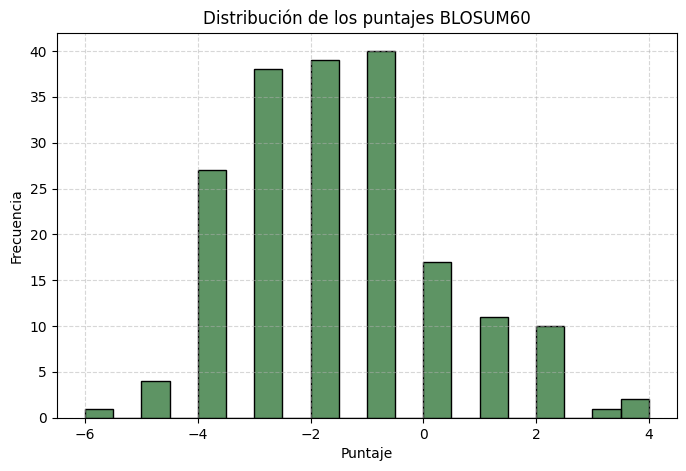

In [5]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

matrix = blosum60_df.values

values = matrix[np.triu_indices_from(matrix, k=1)]

# --- Graficar ---
plt.figure(figsize=(8,5))
sns.histplot(values, bins=20, color= "#287030")

plt.title("Distribución de los puntajes BLOSUM60")
plt.xlabel("Puntaje")
plt.ylabel("Frecuencia")
plt.grid(True, linestyle="--", alpha=0.5)
plt.show()


La matriz blosum60 tolera bastantes sustituciones de aminoacidos, ya que su porcentaje de identidad entre secuencias es ≥60%. Entonces, si aun así un par de aminoácidos recibe un puntaje negativo, quiere decir que esa sustitución es muy poco probable incluso considerando divergencia (es una penalización más fuerte). Es por esto, que decidimos establecer un umbral de corte de la siguiente manera:
* 1 si dotplot[i,j] ≥ -1
* 0 si dotplot[i,j] < 1

Realizamos una funcion que nos permita filtrar nuestro dot plot de aminoacidos.

    filtrar_dotplot_aminoacidos.

    Parámetros:
    -----------
    matrix : np.ndarray o pd.DataFrame
        Matriz de similitud/puntajes.
    umbral : int o float
        Valor del umbral.
    modo : str, "binario" o "filtrado"
        - "binario": los valores >= umbral → 1, si no → 0
        - "filtrado": los valores >= umbral se conservan, si no → 0

    Retorna:
    --------
    np.ndarray con los valores filtrados

In [6]:
import numpy as np

def filtrar_dotplot_aminoacidos(matrix, umbral, modo="binario"):
    arr = matrix.values if hasattr(matrix, "values") else np.array(matrix)

    if modo == "binario":
        return (arr >= umbral).astype(int)
    elif modo == "filtrado":
        return np.where(arr >= umbral, arr, 0)
    else:
        raise ValueError("El modo debe ser 'binario' o 'filtrado'")


ejemplo de como usarla

[[ 0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0]
 [ 0  0  0  0  0  0  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1]
 [ 0  0  0  0  0  0  1  1  1  1  1  1  1  1  1  1  1  1  1  1 10]
 [ 0  0  0  0  0  0  1  1  1  1  2  2  2  2  2  2  2  2  3  7 10]
 [ 0  0  0  0  0  0  1  1  3  3  3  3  3  3  3  3  3  3  8  8 10]
 [ 0  4  4  8  8  8  8  8  8  8  8  8  8  8  8  8  8 11 11 11 11]
 [ 0  4  4  8  8  8  8  8  8  8  8  8  8  8  8  8 14 14 14 14 14]
 [ 0  4  4  8  8  8  8  8 10 10 10 10 10 10 10 15 15 15 15 15 15]
 [ 0  4  4  8 12 12 12 12 12 12 12 12 12 12 15 15 15 16 16 16 16]
 [ 0  4  4  8 12 12 12 14 14 14 14 14 14 17 17 17 17 17 17 17 17]
 [ 0  4  4  8 12 12 12 14 14 14 14 17 19 19 19 19 19 19 19 19 19]
 [ 0  4  4  8 12 12 12 14 14 14 14 21 21 21 21 21 21 21 21 21 21]
 [ 0  4  4  8 12 12 13 14 14 14 20 21 21 21 21 22 22 22 22 22 22]
 [ 0  4  4  8 12 12 13 14 14 22 22 22 22 22 22 22 22 22 22 22 22]
 [ 0  4  4  8 12 12 13 14 20 22 22 22 22 23 23 24 24 24 24 24 24]
 [ 0  4  4

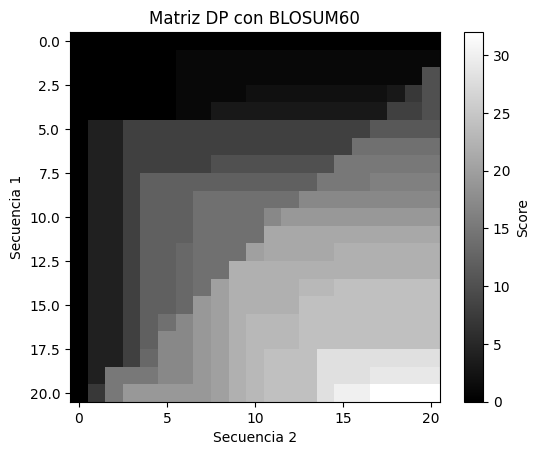

In [7]:

seq1 = "ACDEFGHIKLMNPQRSTVWY"
seq2 = "YWFVTSRQPNMLKIHGFEDC"

matriz_puntaje = puntaje_acum_blosum(seq1, seq2, blosum60_df)

print(matriz_puntaje)

plt.imshow(matriz_puntaje, cmap="gray", origin="upper")
plt.colorbar(label="Score")
plt.title("Matriz DP con BLOSUM60")
plt.xlabel("Secuencia 2")
plt.ylabel("Secuencia 1")
plt.show()

    Calcula el mejor camino de alineamiento usando programación dinámica.
    
    Parámetros
    ----------
    dotplot : np.ndarray
        Matriz de puntajes (ej: salida de generar_dotplot filtrado).
    gap_penalty : int o float
        Penalización por gap.

    Retorna
    -------
    score_matrix : np.ndarray
        Matriz de puntuaciones.
    path : list of tuple
        Camino óptimo (lista de coordenadas).


In [8]:
import numpy as np
def inicializar_matrices(n, m, gap_open, gap_ext):
    score = np.zeros((n, m))
    traceback = np.zeros((n, m), dtype="object")


    # Inicialización (alineamiento global → penalización en bordes)
    for i in range(1, n):
        score[i, 0] = i * gap_ext
        traceback[i, 0] = (i-1, 0)
    for j in range(1, m):
        score[0, j] = j * gap_ext
        traceback[0, j] = (0, j-1)

    hay_gap_en_seq_horizontal = np.zeros((n,m), dtype=int)
    hay_gap_en_seq_vertical = np.zeros((n,m), dtype=int)
    for i in range(1,n):
      hay_gap_en_seq_horizontal[i,0] = 1
    for i in range(1,m):
      hay_gap_en_seq_vertical[0,i] = 1

    return score ,traceback, hay_gap_en_seq_horizontal, hay_gap_en_seq_vertical

def alinear_dotplot(dotplot,gap_open, gap_ext):
    n_rows, n_cols = dotplot.shape
    score, traceback, hay_gap_en_seq_horizontal, hay_gap_en_seq_vertical = inicializar_matrices(n_rows+1, n_cols+1, gap_open, gap_ext)

    # Rellenar matriz de scores
    for i in range(1, n_rows+1):
        for j in range(1, n_cols+1):
            match = score[i-1, j-1] + dotplot[i-1, j-1]
            up = score[i-1, j] + (gap_ext if hay_gap_en_seq_horizontal[i-1][j] else gap_open) #Celda superior
            left = score[i, j-1] + (gap_ext if hay_gap_en_seq_vertical[i][j-1] else gap_open) #Celda izquierda
            best = max(match, up, left)
            score[i, j] = best

            # guardar traceback
            if best == match:
                traceback[i, j] = (i-1, j-1)
            elif best == up:
                hay_gap_en_seq_horizontal[i,j] = 1
                traceback[i, j] = (i-1, j)
            else:
                hay_gap_en_seq_vertical[i,j] = 1
                traceback[i, j] = (i, j-1)

    # Reconstrucción del camino
    path = []
    i, j = n_rows, n_cols
    while (i, j) != (0, 0):
        path.append((i-1, j-1))
        i, j = traceback[i, j]
    path.reverse()

    return score, path


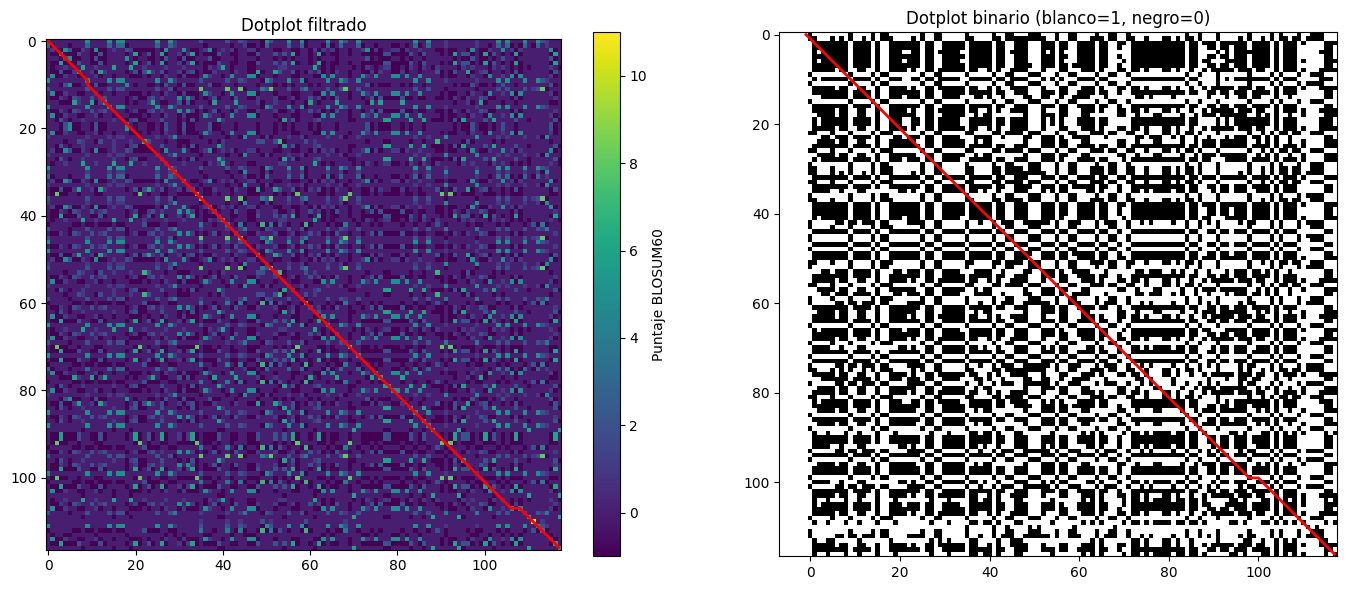

In [9]:
# testeando con secuencias grandes
hemO = "LMSETENQALTFAKRLKADTTAVHDSVDNLVMSVQPFVSKENYIKFLKLQSVFHKAVDHIYKDAELNKAIPELEYMARYDAVTQDLKDLGEEPYKFDKELPYEAGNKAIGWLYCAEG"
coincidencia_blast = "LAPESTRQNLRSQRLNLLTNEPHQRLESLVKSKEPFASRDNFARFVAAQYLFQHDLEPLYRNEALARLFPGLASRARDDAARADLADLGHPVPEGDQSVREADLSLAEALGWLFVSEG"
umbral = -1
GAP_OPEN, GAP_EXT = -11, -1
dotplot_aa = generar_dotplot(hemO, coincidencia_blast, tipo="aminoacido", matriz=blosum60_df)
filtrado = filtrar_dotplot_aminoacidos(dotplot_aa, umbral, modo="filtrado")
filtrado_binario = filtrar_dotplot_aminoacidos(dotplot_aa, umbral, modo="binario")


_, path0 = alinear_dotplot(filtrado, GAP_OPEN, GAP_EXT)
_, path1 = alinear_dotplot(filtrado_binario, GAP_OPEN, GAP_EXT)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Dotplot filtrado normal con viridis
im0 = axes[0].imshow(filtrado, cmap="viridis", interpolation="nearest")
y0, x0 = zip(*path0)
axes[0].plot(x0, y0, color="red", linewidth=2)
axes[0].set_title("Dotplot filtrado")
cbar0 = fig.colorbar(im0, ax=axes[0])
cbar0.set_label("Puntaje BLOSUM60")

# Dotplot binario en blanco y negro
axes[1].imshow(filtrado_binario, cmap="gray_r", interpolation="nearest")
y1, x1 = zip(*path1)
axes[1].plot(x1, y1, color="red", linewidth=2)
axes[1].set_title("Dotplot binario (blanco=1, negro=0)")

plt.tight_layout()
plt.show()



In [10]:
import re
def score(alin1, alin2, gap_open, gap_ext):
    if len(alin1) != len(alin2): raise ValueError("Alineamiento invalido: distinto largo")
    gaps_alineamiento1= re.findall(r"-+", alin1)
    gaps_alineamiento2= re.findall(r"-+", alin2)
    score = 0
    for gaps in gaps_alineamiento1:
        score += gap_open + gap_ext * (len(gaps)-1)
    for gaps in gaps_alineamiento2:
        score += gap_open + gap_ext * (len(gaps)-1)
    for i in range(len(alin1)):
        if alin1[i] != "-"  and alin2[i] != "-":
            score += blosum60_df.loc[alin1[i], alin2[i]]
    print("Score:", score)
    return score



In [38]:
def build_alignment_from_coords(seq1, seq2, coords):
    """
    Reconstruye dos secuencias alineadas y la línea de matches '*' a partir
    de una lista de coordenadas (x,y) en orden de camino.

    seq1, seq2 : strings
    coords      : list de tuplas (x,y)
    coords_0based : True si las coords son 0-based; False si son 1-based
    """
    if not coords:
        raise ValueError("coords vacía")
    a1, a2, m = [], [], []

    def append_pair(i, j):
        a1.append(seq1[i])
        a2.append(seq2[j])
        m.append('*' if seq1[i] == seq2[j] else ' ')

    def append_horiz(i):  # avance en seq1, gap en seq2
        a1.append(seq1[i])
        a2.append('-')
        m.append(' ')

    def append_vert(j):   # avance en seq2, gap en seq1
        a1.append('-')
        a2.append(seq2[j])
        m.append(' ')

    # primer punto
    x0, y0 = coords[0]
    append_pair(x0, y0)
    prev_x, prev_y = x0, y0

    for (x, y) in coords[1:]:
        dx, dy = x - prev_x, y - prev_y

        # diagonales
        while dx > 0 and dy > 0:
            prev_x += 1
            prev_y += 1
            append_pair(prev_x, prev_y)
            dx -= 1
            dy -= 1
        # horizontales
        while dx > 0:
            prev_x += 1
            append_horiz(prev_x)
            dx -= 1
        # verticales
        while dy > 0:
            prev_y += 1
            append_vert(prev_y)
            dy -= 1

        prev_x, prev_y = x, y
    alin1, alin2, matchs = "".join(a1), "".join(a2), "".join(m)
    i = 0
    while(alin1[i] == '-' or alin2[i] == '-'):
      i+=1
    alin1, alin2, matchs = alin1[i:], alin2[i:], matchs[i:]
    j = 0
    while(alin1[len(alin1) -j-1] == '-' or alin2[len(alin2) -j-1] == '-'):
        j += 1

    alin1, alin2, matchs = alin1[: len(alin1) - j], alin2[: len(alin2) - j], matchs[:len(matchs) -j]
    return alin1, alin2, matchs



## Evaluaremos nuestra funcion de alineamiento de proteinas

In [39]:
hemO = 'LMSETENQALTFAKRLKADTTAVHDSVDNLVMSVQPFVSKENYIKFLKLQSVFHKAVDHIYKDAELNKAIPELEYMARYDAVTQDLKDLGEEPYKFDKELPYEAGNKAIGWLYCAEG'
coincidencia_blast = 'LAPESTRQNLRSQRLNLLTNEPHQRLESLVKSKEPFASRDNFARFVAAQYLFQHDLEPLYRNEALARLFPGLASRARDDAARADLADLGHPVPEGDQSVREADLSLAEALGWLFVSEG'

In [40]:
dotplot_aa = generar_dotplot(hemO, coincidencia_blast, tipo="aminoacido", matriz=blosum60_df)
filtrado = filtrar_dotplot_aminoacidos(dotplot_aa, umbral, modo="filtrado")
_, path0 = alinear_dotplot(filtrado, GAP_OPEN, GAP_EXT)

a1, a2, m = build_alignment_from_coords(hemO, coincidencia_blast, path0)
b1 = 'LMSETENQALTFAKRLKADTTAVHDSVDNLVMSVQPFVSKENYIKFLKLQSVFHKAVDHIYKDAELNKAIPELEYMARYDAVTQDLKDLGEEPYKFDKELPYEAG---NKAIGWLYCAEG'
b2 = 'LAPESTRQNLR-SQRLNLLTNEPHQRLESLVKSKEPFASRDNFARFVAAQYLFQHDLEPLYRNEALARLFPGLASRARDDAARADLADLGHPVPEGDQSV-READLSLAEALGWLFVSEG'


print('ALINEAMIENTO BLAST')
print(b1)
print('L  E+  Q L  ++RL   T   H  +++LV S +PF S++N+ +F+  Q +F   ++ +Y++  L +  P L   AR DA   DL DLG    + D+ +  EA     +A+GWL+ +EG')
print(b2)
print( score(b1,b2,-11,-1))

print()

print('NUESTRO ALINEAMIENTO')
print(a1)
print(m)
print(a2)
print(score(a1,a2,-11,-1))

ALINEAMIENTO BLAST
LMSETENQALTFAKRLKADTTAVHDSVDNLVMSVQPFVSKENYIKFLKLQSVFHKAVDHIYKDAELNKAIPELEYMARYDAVTQDLKDLGEEPYKFDKELPYEAG---NKAIGWLYCAEG
L  E+  Q L  ++RL   T   H  +++LV S +PF S++N+ +F+  Q +F   ++ +Y++  L +  P L   AR DA   DL DLG    + D+ +  EA     +A+GWL+ +EG
LAPESTRQNLR-SQRLNLLTNEPHQRLESLVKSKEPFASRDNFARFVAAQYLFQHDLEPLYRNEALARLFPGLASRARDDAARADLADLGHPVPEGDQSV-READLSLAEALGWLFVSEG
Score: 180
180

NUESTRO ALINEAMIENTO
LMSETENQALTFAKRLKADTTAVHDSVDNLVMSVQPFVSKENYIKFLKLQSVFHKAVDHIYKDAELNKAIPELEYMARYDAVTQDLKDLGEEPYKFDKELPYEAGNKA--IGWLYCAEG
*  *   * *    **   *   *     ** *  ** *  *   *   *  *       *    *    * *   ** **   ** ***      *          *   ***   **
LAPESTRQNL-RSQRLNLLTNEPHQRLESLVKSKEPFASRDNFARFVAAQYLFQHDLEPLYRNEALARLFPGLASRARDDAARADLADLGHPVPEGDQSVREADLSLAEALGWLFVSEG
Score: 168
168


Esto fue lo obtenido por el blast

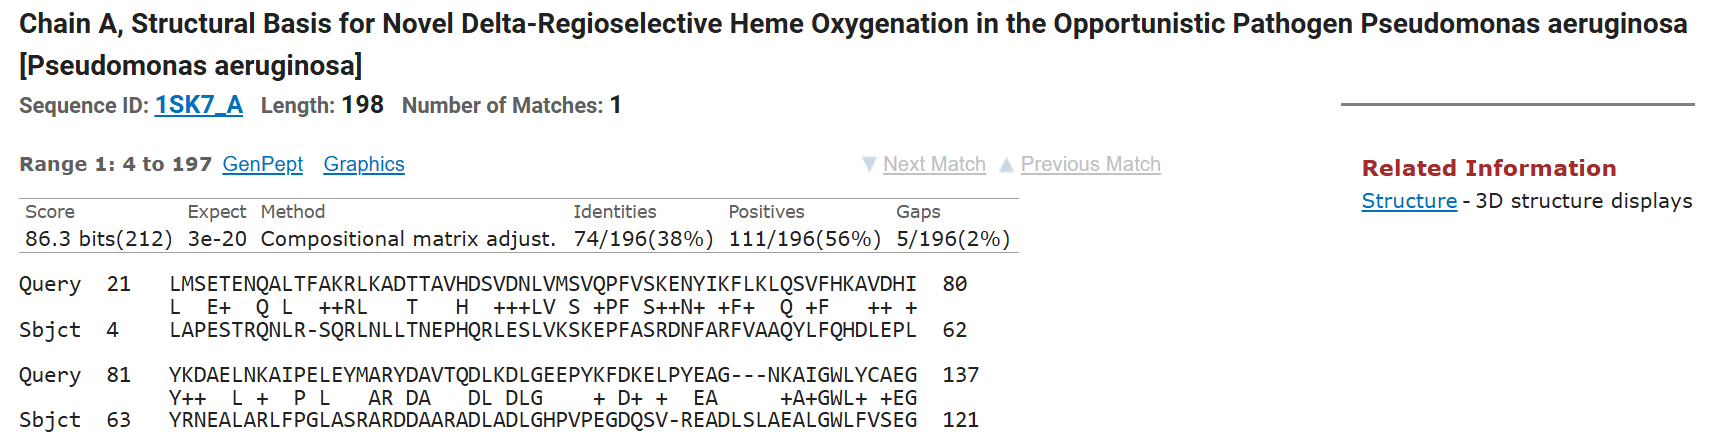

### Testeamos entre las siguientes globinas

In [21]:
hemoglobina_subunidad_beta = 'MVLSPADKTNVKAAWGKVGAHAGEYGAEALERMFLSFPTTKTYFPHFDLSHGSAQVKGHGKKVADALTNAVAHVDDMPNALSALSDLHAHKLRVDPVNFKLLSHCLLVTLAAHLPAEFTPAVHASLDKFLASVSTVLTSKYR'
mioglobina = 'MGLSDGEWQLVLNVWGKVEADIPGHGQEVLIRLFKGHPETLEKFDKFKHLKSEDEMKASEDLKKHGATVLTALGGILKKKGHHEAEIKPLAQSHATKHKIPVKYLEFISECIIQVLQSKHPGDFGADAQGAMNKALELFRKDMASNYKELGFQG'
neuroglobina = 'MERPEPELIRQSWRAVSRSPLEHGTVLFARLFALEPDLLPLFQYNCRQFSSPEDCLSSPEFLDHIRKVMLVIDAAVTNVEDLSSLEEYLASLGRKHRAVGVKLSSFSTVGESLLYMLEKCLGPAFTPATRAAWSQLYGAVVQAMSRGWDGE'

## Hemoglobina beta vs mioglobina


In [51]:
dotplot_aa = generar_dotplot(hemoglobina_subunidad_beta, mioglobina, tipo="aminoacido", matriz=blosum60_df)
filtrado = filtrar_dotplot_aminoacidos(dotplot_aa, umbral, modo="filtrado")
_, path0 = alinear_dotplot(filtrado, GAP_OPEN, GAP_EXT)

a1, a2, m = build_alignment_from_coords(hemoglobina_subunidad_beta, mioglobina, path0)
b1 = 'MVLSPADKTNVKAAWGKVGAHAGEYGAEALERMFLSFPTTKTYFPHF------DLSHGSAQVKGHGKKVADALTNAVAHVDDMPNALSALSDLHAHKLRVDPVNF-KLLSHCLLVTLAAHLPAEFTPAVHASLDKFLASVSTVLTSKYR'
b2 = 'MGLSDGEWQLVLNVWGKVEADIPGHGQEVLIRLFKGHPETLEKFDKFKHLKSEDEMKASEDLKKHGATVLTALGGILKKKGHHEAEIKPLAQSHATKHKI-PVKYLEFISECIIQVLQSKHPGDFGADAQGAMNKALELFRKDMASNYK'

print('ALINEAMIENTO BLAST')
print(b1)
print('M LS  +   V   WGKV A    +G E L R+F   P T   F  F      D    S  +K HG  V  AL   +         +  L+  HA K ++ PV + + +S C++  L +  P +F      +++K L      + S Y+')
print(b2)
print( score(b1,b2,-11,-1))

print()

print('NUESTRO ALINEAMIENTO')
print(a1)
print(m)
print(a2)
print(score(a1,a2,-11,-1))


ALINEAMIENTO BLAST
MVLSPADKTNVKAAWGKVGAHAGEYGAEALERMFLSFPTTKTYFPHF------DLSHGSAQVKGHGKKVADALTNAVAHVDDMPNALSALSDLHAHKLRVDPVNF-KLLSHCLLVTLAAHLPAEFTPAVHASLDKFLASVSTVLTSKYR
M LS  +   V   WGKV A    +G E L R+F   P T   F  F      D    S  +K HG  V  AL   +         +  L+  HA K ++ PV + + +S C++  L +  P +F      +++K L      + S Y+
MGLSDGEWQLVLNVWGKVEADIPGHGQEVLIRLFKGHPETLEKFDKFKHLKSEDEMKASEDLKKHGATVLTALGGILKKKGHHEAEIKPLAQSHATKHKI-PVKYLEFISECIIQVLQSKHPGDFGADAQGAMNKALELFRKDMASNYK
Score: 146
146

NUESTRO ALINEAMIENTO
MVLSPADKTNVKAAWGKVGAHAGEYGAEALERMFLSFPTTKTYF------PHFDLSHGSAQVKGHGKKVADALTNAVAHVDDMPNALSALSDLHAHKLRVDPVNFKLLSHCLLVTLAAHLPAEFTPAVHASLDKFLASVSTVLTSKYR
* **      *   **** *     * * * * *   * *   *         *    *   * **  *  **                *   ** *           * *    *    *  *         * *        * * 
MGLSDGEWQLVLNVWGKVEADIPGHGQEVLIRLFKGHPETLEKFDKFKHLKSEDEMKASEDLKKHGATVLTALGGILKKKGHHEAEIKPLAQSHATKHKIPVKYLEFISECIIQVLQSKHPGDFGADAQGAMNKALELFRKDMASNYK
Score: 132
132


## Hemoglobina beta vs neuroglobina


In [52]:
dotplot_aa = generar_dotplot(hemoglobina_subunidad_beta, neuroglobina, tipo="aminoacido", matriz=blosum60_df)
filtrado = filtrar_dotplot_aminoacidos(dotplot_aa, umbral, modo="filtrado")
_, path0 = alinear_dotplot(filtrado, GAP_OPEN, GAP_EXT)

a1, a2, m = build_alignment_from_coords(hemoglobina_subunidad_beta, neuroglobina, path0)
b1 = 'VKAAWGKVGAHAGEYGAEALERMFLSFPTTKTYF---------PHFDLSHGSAQVKGHGKKVADALTNAVAHVDDMPNALSALSDL-HAHK-LRVDPVNFKLLSHCLLVTLAAHLPAEFTPAVHASLDKFLASVSTVLTSKY'
b2 = 'IRQSWRAVSRSPLEHGTVLFARLFALEPDLLPLFQYNCRQFSSPEDCLS--SPEFLDHIRKVMLVIDAAVTNVEDLSSLEEYLASLGRKHRAVGVKLSSFSTVGESLLYMLEKCLGPAFTPATRAAWSQLYGAVVQAMSRGW'




print('ALINEAMIENTO BLAST')
print(b1)
print('++ +W  V     E+G     R+F   P     F         P   LS  S +   H +KV   +  AV +V+D+ +    L+ L   H+ + V   +F  +   LL  L   L   FTPA  A+  +   +V   ++  +')
print(b2)
print( score(b1,b2,-11,-1))

print()

print('NUESTRO ALINEAMIENTO')
print(a1)
print(m)
print(a2)
print(score(a1,a2,-11,-1))



ALINEAMIENTO BLAST
VKAAWGKVGAHAGEYGAEALERMFLSFPTTKTYF---------PHFDLSHGSAQVKGHGKKVADALTNAVAHVDDMPNALSALSDL-HAHK-LRVDPVNFKLLSHCLLVTLAAHLPAEFTPAVHASLDKFLASVSTVLTSKY
++ +W  V     E+G     R+F   P     F         P   LS  S +   H +KV   +  AV +V+D+ +    L+ L   H+ + V   +F  +   LL  L   L   FTPA  A+  +   +V   ++  +
IRQSWRAVSRSPLEHGTVLFARLFALEPDLLPLFQYNCRQFSSPEDCLS--SPEFLDHIRKVMLVIDAAVTNVEDLSSLEEYLASLGRKHRAVGVKLSSFSTVGESLLYMLEKCLGPAFTPATRAAWSQLYGAVVQAMSRGW
Score: 89
89

NUESTRO ALINEAMIENTO
MVLSPADKTNVKAAWGKVGAHAGEYGAEALERMFLSFPTTKTYFPHFDLSHGSAQ-------VKGHGKKVADALTNAVAHVDDMPNALSALSDLHA--HKLRVDPVNFKLLSHCLLVTLAAHLPAEFTPAVHASLDK-FLASVSTVLTSKYR
              *  *     * *     * *   *     *        *            *  **      **  * *       *  *        *    *      **  *   *   ****  *       * *         
E-MERPEPELIRQSWRAVSRSPLEHGTVLFARLFALEPDLLPLFQYNCRQFSSPEDCLSSPEFLDHIRKVMLVIDAAVTNVEDLSSLEEYLASLGRKHRAVGVKLSSFSTVGESLLYMLEKCLGPAFTPATRAAWSQLYGAVVQAMSRGWDG
Score: 34
34


### Hemoglogina beta vs neuroglobina acortadas
Aqui alineamos las subsecuencias de las proteinas que fueron alineadas por blast, recortando parte del inicio y fin de las proteinas originales.

In [53]:
beta_corta='VKAAWGKVGAHAGEYGAEALERMFLSFPTTKTYFPHFDLSHGSAQVKGHGKKVADALTNAVAHVDDMPNALSALSDLHAHKLRVDPVNFKLLSHCLLVTLAAHLPAEFTPAVHASLDKFLASVSTVLTSKY'
neuro_corta = 'IRQSWRAVSRSPLEHGTVLFARLFALEPDLLPLFQYNCRQFSSPEDCLSSPEFLDHIRKVMLVIDAAVTNVEDLSSLEEYLASLGRKHRAVGVKLSSFSTVGESLLYMLEKCLGPAFTPATRAAWSQLYGAVVQAMSRGW'
dotplot_aa = generar_dotplot(beta_corta, neuro_corta, tipo="aminoacido", matriz=blosum60_df)
filtrado = filtrar_dotplot_aminoacidos(dotplot_aa, umbral, modo="filtrado")
_, path0 = alinear_dotplot(filtrado, GAP_OPEN, GAP_EXT)

a1, a2, m = build_alignment_from_coords(beta_corta, neuro_corta, path0)
print('ALINEAMIENTO BLAST')
print(b1)
print('++ +W  V     E+G     R+F   P     F         P   LS  S +   H +KV   +  AV +V+D+ +    L+ L   H+ + V   +F  +   LL  L   L   FTPA  A+  +   +V   ++  +')
print(b2)
print( score(b1,b2,-11,-1))

print()

print('NUESTRO ALINEAMIENTO')
print(a1)
print(m)
print(a2)
print(score(a1,a2,-11,-1))



ALINEAMIENTO BLAST
VKAAWGKVGAHAGEYGAEALERMFLSFPTTKTYF---------PHFDLSHGSAQVKGHGKKVADALTNAVAHVDDMPNALSALSDL-HAHK-LRVDPVNFKLLSHCLLVTLAAHLPAEFTPAVHASLDKFLASVSTVLTSKY
++ +W  V     E+G     R+F   P     F         P   LS  S +   H +KV   +  AV +V+D+ +    L+ L   H+ + V   +F  +   LL  L   L   FTPA  A+  +   +V   ++  +
IRQSWRAVSRSPLEHGTVLFARLFALEPDLLPLFQYNCRQFSSPEDCLS--SPEFLDHIRKVMLVIDAAVTNVEDLSSLEEYLASLGRKHRAVGVKLSSFSTVGESLLYMLEKCLGPAFTPATRAAWSQLYGAVVQAMSRGW
Score: 89
89

NUESTRO ALINEAMIENTO
VKAAWGKVGAHAGEYGAEALERMFLSFPTTKTYFPHFDLSHGSAQ-------VKGHGKKVADALTNAVAHVDDMPNALSALSDLHA--HKLRVDPVNFKLLSHCLLVTLAAHLPAEFTPAVHASLDKFLASVSTVLTSKY
    *  *     * *     * *   *     *        *            *  **      **  * *       *  *        *    *      **  *   *   ****  *        *        
IRQSWRAVSRSPLEHGTVLFARLFALEPDLLPLFQYNCRQFSSPEDCLSSPEFLDHIRKVMLVIDAAVTNVEDLSSLEEYLASLGRKHRAVGVKLSSFSTVGESLLYMLEKCLGPAFTPATRAAWSQLYGAVVQAMSRGW
Score: 77
77


## Mioglobina vs neuroglobina

In [54]:
dotplot_aa = generar_dotplot(mioglobina, neuroglobina, tipo="aminoacido", matriz=blosum60_df)
filtrado = filtrar_dotplot_aminoacidos(dotplot_aa, umbral, modo="filtrado")
_, path0 = alinear_dotplot(filtrado, GAP_OPEN, GAP_EXT)

a1, a2, m = build_alignment_from_coords(mioglobina, neuroglobina, path0)
b1 = 'EWQLVLNVWGKVEADIPGHGQEVLIRLFKGHPETLEKFD-KFKHLKSEDEMKASEDLKKHGATVLTAL'
b2 = 'EPELIRQSWRAVSRSPLEHGTVLFARLFALEPDLLPLFQYNCRQFSSPEDCLSSPEFLDHIRKVMLVI'

print('ALINEAMIENTO BLAST')
print(b1)
print('E +L+   W  V      HG  +  RLF   P+ L  F    +   S ++  +S +   H')
print(b2)
print( score(b1,b2,-11,-1))

print()

print('NUESTRO ALINEAMIENTO')
print(a1)
print(m)
print(a2)
print(score(a1,a2,-11,-1))


ALINEAMIENTO BLAST
EWQLVLNVWGKVEADIPGHGQEVLIRLFKGHPETLEKFD-KFKHLKSEDEMKASEDLKKHGATVLTAL
E +L+   W  V      HG  +  RLF   P+ L  F    +   S ++  +S +   H
EPELIRQSWRAVSRSPLEHGTVLFARLFALEPDLLPLFQYNCRQFSSPEDCLSSPEFLDHIRKVMLVI
Score: 53
53

NUESTRO ALINEAMIENTO
MGLSDGEWQLVLNVWGKVEADIPGHGQEVLIRLFKGHPETLEKF-DKFKHLKSEDEMKASEDLKKHGATVLTALGGILKKKGHHEAEIKPLAQSHATKHKIPVKYLEFISECIIQVLQSKHPGDFGADAQGAMNKALELFRKDMASNYKELGFQG
      *  *    *  *      **     ***   *  *  *        *      *     *   *                    ** *   **      *   *      *        *     *   *                   
E-MERPEPELIRQSWRAVSRSPLEHGTVLFARLFALEPDLLPLFQYNCRQFSSPEDCLSSPEFLDHIRKVMLVIDAAVTNVEDLSSLEEYLA-SLGRKHRAVGVKLSSFS-TVGESLLYMLEKCLGPAFTPATRAAWSQLYGAVVQAMSRGWDGE
Score: -23
-23


### Mioglobina vs neuroglobina recortadas
Aqui alineamos las subsecuencias de las proteinas que fueron alineadas por blast, recortando parte del inicio y fin de las proteinas originales.

In [55]:
beta_corta='EWQLVLNVWGKVEADIPGHGQEVLIRLFKGHPETLEKFDKFKHLKSEDEMKASEDLKKHGATVLTAL'
neuro_corta = 'EPELIRQSWRAVSRSPLEHGTVLFARLFALEPDLLPLFQYNCRQFSSPEDCLSSPEFLDHIRKVMLVI'
dotplot_aa = generar_dotplot(beta_corta, neuro_corta, tipo="aminoacido", matriz=blosum60_df)
filtrado = filtrar_dotplot_aminoacidos(dotplot_aa, umbral, modo="filtrado")
_, path0 = alinear_dotplot(filtrado, GAP_OPEN, GAP_EXT)

a1, a2, m = build_alignment_from_coords(beta_corta, neuro_corta, path0)
print('ALINEAMIENTO BLAST')
print(b1)
print('++ +W  V     E+G     R+F   P     F         P   LS  S +   H +KV   ')
print(b2)
print( score(b1,b2,-11,-1))

print()

print('NUESTRO ALINEAMIENTO')
print(a1)
print(m)
print(a2)
print(score(a1,a2,-11,-1))



ALINEAMIENTO BLAST
EWQLVLNVWGKVEADIPGHGQEVLIRLFKGHPETLEKFD-KFKHLKSEDEMKASEDLKKHGATVLTAL
++ +W  V     E+G     R+F   P     F         P   LS  S +   H +KV   
EPELIRQSWRAVSRSPLEHGTVLFARLFALEPDLLPLFQYNCRQFSSPEDCLSSPEFLDHIRKVMLVI
Score: 53
53

NUESTRO ALINEAMIENTO
EWQLVLNVWGKVEADIPGHGQEVLIRLFKGHPETLEKF-DKFKHLKSEDEMKASEDLKKHGATVLTAL
*  *    *  *      **     ***   *  *  *        *      *     *   *    
EPELIRQSWRAVSRSPLEHGTVLFARLFALEPDLLPLFQYNCRQFSSPEDCLSSPEFLDHIRKVMLVI
Score: 49
49


Nuestro alineamiento encuentra varios matchs, pero tambien pone muchos gaps, teniendo diferencias notorias con el alineamiento de blast.

Algunas diferencias que encontramos en internet tambien son las siguientes:
* blast utiliza otra matriz de blosum, por lo que las diferencias podrian deberse a eso.
* blast prioriza un alineamiento local, mientras que nosotros estamos buscando un alineamiento global
* blast mira tambien los positives, y nosotros no